In [1]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "num_seeds": 1,             # Number of random seeds to try
    "use_adaptive_gamma": True,  # Whether to select gamma adaptively for MMD
    "num_permutations": 100,     # Number of permutations for the MMD test
    "alpha": 0.05                # Significance level for drift detection
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# MMD Computation
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    """
    MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    Return sqrt(MMD^2).
    """
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    """
    Simple heuristic: gamma = 1/(2*median_of_pairwise_distance^2).
    """
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# Permutation Test for MMD
###############################################################################
def permutation_test_mmd(baseline_embs, new_embs, gamma=0.5, num_permutations=100):
    """
    Permutation (randomization) test to determine whether baseline_embs and
    new_embs come from the same distribution.

    1) Pool the embeddings together.
    2) Permute them. Split into two subsets of the same sizes as baseline/new.
    3) Compute MMD for each random split -> distribution under null hypothesis.
    4) Return actual MMD, distribution of permuted MMDs, and a p-value.
    """
    actual_mmd = compute_mmd(baseline_embs, new_embs, gamma)

    combined = np.concatenate([baseline_embs, new_embs], axis=0)
    n_baseline = len(baseline_embs)
    n_combined = len(combined)

    perm_mmds = []
    for _ in range(num_permutations):
        perm_indices = np.random.permutation(n_combined)
        Xperm = combined[perm_indices[:n_baseline]]
        Yperm = combined[perm_indices[n_baseline:]]
        pmmd = compute_mmd(Xperm, Yperm, gamma)
        perm_mmds.append(pmmd)

    perm_mmds = np.array(perm_mmds)
    # p-value = fraction of permutations >= actual
    p_val = np.mean(perm_mmds >= actual_mmd)
    return actual_mmd, perm_mmds, p_val

###############################################################################
# Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    set_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device: {device}")

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs_list = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs_list.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs_list, axis=0)

            # Fit PCA for optional analysis
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            # Adaptive gamma
            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            # For each drift_strength, run a permutation test
            for drift_strength in args["drift_strengths"]:
                start_time = time.time()

                drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)

                new_embs_list = []
                for b in batch_generator(drifted_texts, args["batch_size"]):
                    emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                    new_embs_list.append(emb_b)
                new_embs = np.concatenate(new_embs_list, axis=0)

                actual_mmd, perm_mmds, p_val = permutation_test_mmd(
                    baseline_embs,
                    new_embs,
                    gamma=gamma_val,
                    num_permutations=args["num_permutations"]
                )

                drift_detected = bool(p_val < args["alpha"])

                end_time = time.time()
                time_taken = end_time - start_time

                key = (dataset_name, model_name, drift_strength)
                # Store perm_mmds so we can visualize the distribution if needed
                results[key].append({
                    "actual_mmd": actual_mmd,
                    "perm_mmds": perm_mmds,  
                    "p_val": p_val,
                    "drift_detected": drift_detected,
                    "time_taken": time_taken,
                    "seed": seed
                })

    return results

###############################################################################
# Multiple Seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)
    print("Data collection (all seeds) done!")
    return all_results

###############################################################################
# Visualization Functions
###############################################################################
def plot_results(all_results, alpha=0.05):
    """
    Plots MMD and p-value vs. drift strength for each (dataset, model).
    Shows points where drift was detected, and a reference line at p=alpha.
    """
    from collections import defaultdict
    grouped = defaultdict(list)
    
    # Organize data by (dataset, model)
    for (dataset_name, model_name, drift_strength), records in all_results.items():
        # If multiple seeds, you might want to average. Here we just take the first record
        r = records[0]
        grouped[(dataset_name, model_name)].append(
            (drift_strength, r["actual_mmd"], r["p_val"], r["drift_detected"])
        )

    # Plot for each (dataset, model) pair
    for (dataset_name, model_name), vals in grouped.items():
        vals.sort(key=lambda x: x[0])  # sort by drift_strength
        drift_strengths = [v[0] for v in vals]
        mmds = [v[1] for v in vals]
        p_values = [v[2] for v in vals]
        drift_flags = [v[3] for v in vals]

        # Create subplots: MMD on left, p-value on right
        plt.figure(figsize=(10, 4))

        # --- Left: MMD vs. drift_strength ---
        plt.subplot(1, 2, 1)
        plt.plot(drift_strengths, mmds, marker='o', label="MMD")
        # Mark points where drift is detected
        for ds, mmd_val, detected in zip(drift_strengths, mmds, drift_flags):
            if detected:
                plt.scatter(ds, mmd_val, color='red', s=80, marker='x', zorder=5)
        plt.title(f"MMD vs. Drift Strength\n{dataset_name} | {model_name}")
        plt.xlabel("Drift Strength")
        plt.ylabel("MMD")
        plt.grid(True)
        plt.legend()

        # --- Right: p-value vs. drift_strength ---
        plt.subplot(1, 2, 2)
        plt.plot(drift_strengths, p_values, marker='o', label="p-value")
        # Horizontal line = alpha
        plt.axhline(y=alpha, color='r', linestyle='--', label=f"alpha={alpha}")
        plt.title("p-value vs. Drift Strength")
        plt.xlabel("Drift Strength")
        plt.ylabel("p-value")
        plt.ylim([0, 1])
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

def plot_permutation_distribution(all_results, dataset, model, drift_strength):
    """
    Plots a histogram of permuted MMD values vs. the actual MMD
    for a specific (dataset, model, drift_strength).
    """
    import matplotlib.pyplot as plt
    
    key = (dataset, model, drift_strength)
    if key not in all_results:
        print("No results found for that key:", key)
        return
    
    # Just take the first record if multiple seeds
    record = all_results[key][0]
    if "perm_mmds" not in record:
        print("No perm_mmds stored in results. Update your code to save it.")
        return
    
    perm_mmds = record["perm_mmds"]
    actual_mmd = record["actual_mmd"]
    p_val = record["p_val"]

    plt.figure(figsize=(7, 5))
    plt.hist(perm_mmds, bins=20, alpha=0.7, color='blue', edgecolor='black', label="Permuted MMDs")
    plt.axvline(x=actual_mmd, color='red', linewidth=2, label=f"Actual MMD={actual_mmd:.4f}")
    plt.title(f"Permutation MMD Distribution\n{dataset} | {model} | drift={drift_strength}\n p-value={p_val:.3f}")
    plt.xlabel("MMD")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

###############################################################################
# Main Execution
###############################################################################
all_results = collect_data_multiple_seeds(args)

# Print summary
for k, records in all_results.items():
    dataset_name, model_name, drift_strength = k
    print(f"\n=== Results for dataset={dataset_name}, model={model_name}, drift_strength={drift_strength} ===")
    for r in records:
        print(
            f" Seed={r['seed']} | MMD={r['actual_mmd']:.4f} "
            f"| p-value={r['p_val']:.4f} "
            f"| Drift Detected={r['drift_detected']} "
            f"| Time={r['time_taken']:.2f}s"
        )

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[Seed=0] --- Using Model: bert-base-uncased ---
Data collection (all seeds) done!

=== Results for dataset=yelp_review_full, model=nlpaueb/sec-bert-base, drift_strength=0.0 ===
 Seed=0 | MMD=0.0360 | p-value=0.9300 | Drift Detected=False | Time=5.75s

=== Results for dataset=yelp_review_full, model=nlpaueb/sec-bert-base, drift_strength=0.25 ===
 Seed=0 | MMD=0.1622 | p-value=0.0000 | Drift Detected=True | Time=5.79s

=== Results for dataset=yelp_review_full, model=nlpaueb/sec-bert-base, drift_strength=0.5 ===
 Seed=0 | MMD=0.2757 | p-value=0.0000 | Drift Detected=True | Time=5.75s

=== Results for dataset=yelp_review_full, model=nlpaueb/sec-bert-base, drift_strength=0.75 ===
 Seed=0 | MMD=0.3357 | p-value=0.0000 | Drift Detected=True | Time=5.79s

=== Results for dataset=yelp_review_full, model=nlpaueb/sec-bert-base, drift_strength=1.0 ===
 Seed=0 | MMD=0.3525 | p-value=0.0000 | Drift Detected=True | Time=5.86s

=== Results for dataset=yelp_review_full, model=bert-base-uncased, drift_s

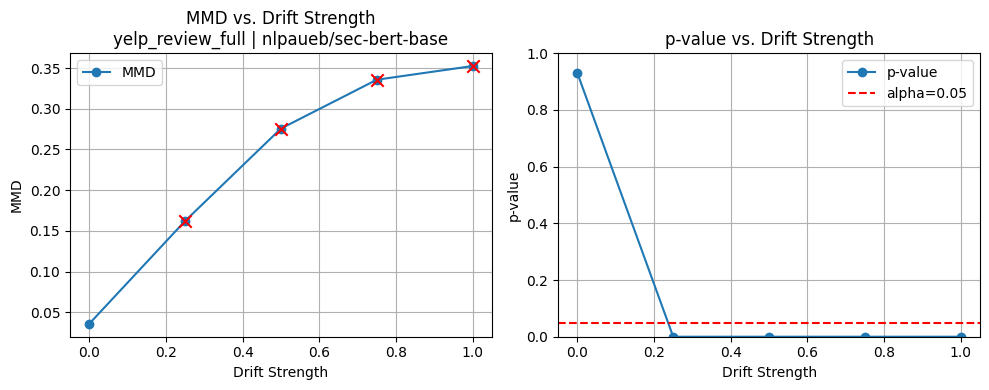

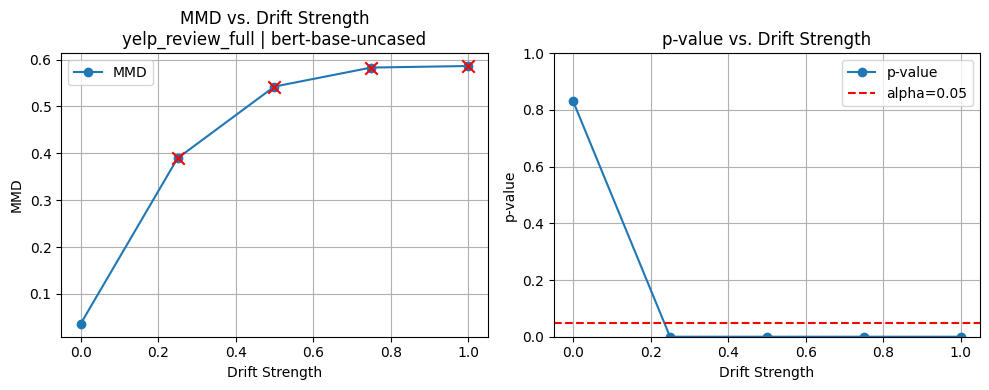

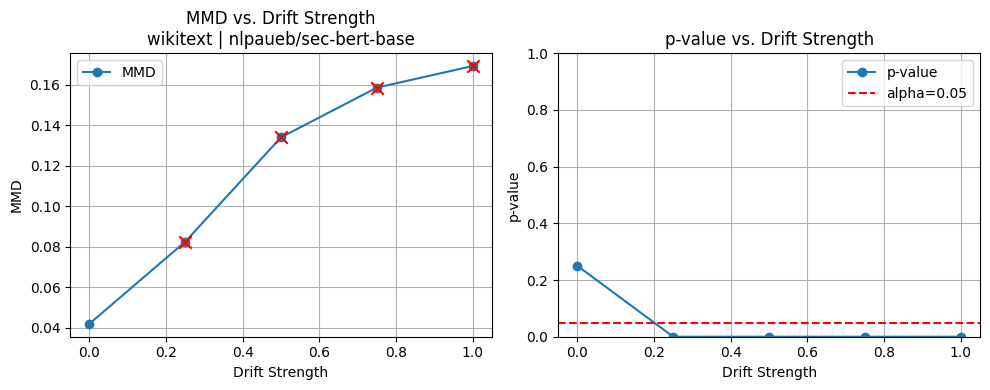

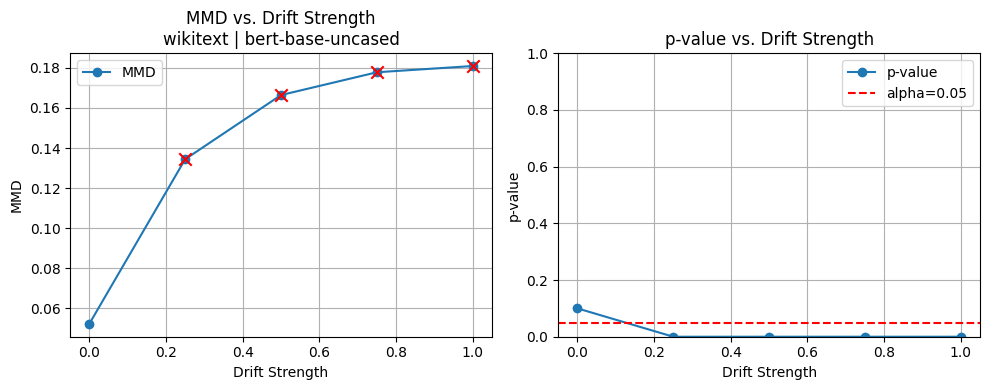

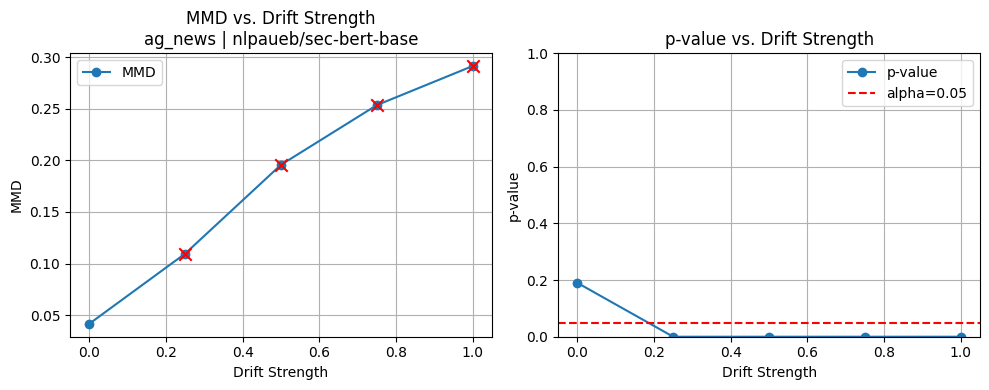

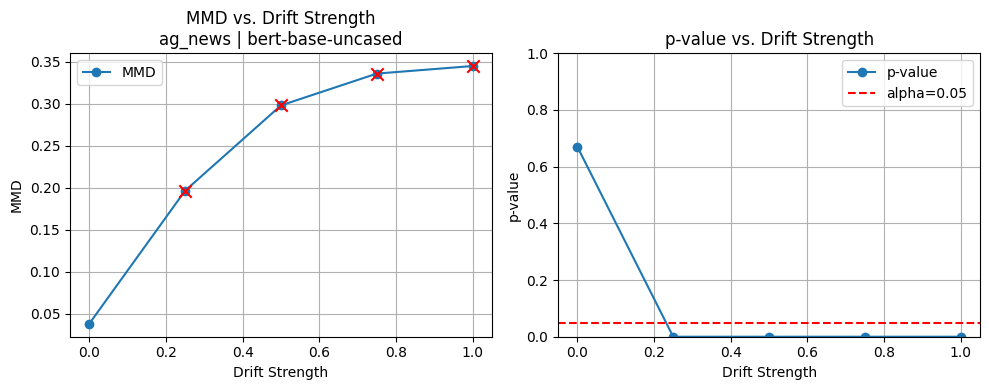

In [2]:
# 1) MMD and p-value vs. drift strength
plot_results(all_results, alpha=args["alpha"])

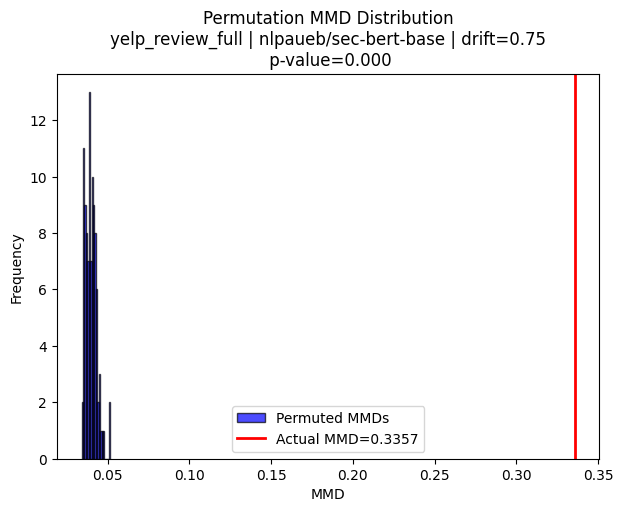

In [3]:
# plot_permutation_distribution(all_results, 
#                               dataset="yelp_review_full", 
#                               model="nlpaueb/sec-bert-base", 
#                               drift_strength=0.75)